In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset = "/content/drive/MyDrive/deeplearning_project/Data/Data"
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [5]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [6]:
class_names = train_dataset.class_names
print(class_names)
num_classes = len(class_names)
print(num_classes)

['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
6


In [7]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [8]:
num_classes

6

## Base Model (CNN2D)

In [9]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# stpe:1
# Convlution layer: 1
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

# Convlution layer: 2
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

# Convlution layer: 3
model.add(tf.keras.layers.Conv2D(128, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

# step: 2
# Flattening Layer
model.add(tf.keras.layers.Flatten())

# step: 3
# Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

#Output layer
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# COMPILATION
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
EPOCHS = 10

In [13]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 325s 14s/step - accuracy: 0.2090 - loss: 2.3909 - val_accuracy: 0.1921 - val_loss: 1.9436
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 94s 4s/step - accuracy: 0.2966 - loss: 1.6671 - val_accuracy: 0.3842 - val_loss: 1.5266
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.4887 - loss: 1.3814 - val_accuracy: 0.5141 - val_loss: 1.3093
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 149s 4s/step - accuracy: 0.6116 - loss: 1.1431 - val_accuracy: 0.5593 - val_loss: 1.1740
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 134s 4s/step - accuracy: 0.7119 - loss: 0.8205 - val_accuracy: 0.4520 - val_loss: 1.6475
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 147s 4s/step - accuracy: 0.7910 - loss: 0.6606 - val_accuracy: 0.5932 - val_loss: 1.2372
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 105s 5s/step - accuracy: 0.8701 - loss: 0.3567 - val_accuracy: 0.5424 - val_loss: 1.5726
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.9336 - loss: 0.2266 - val_accuracy: 0.6554 - v

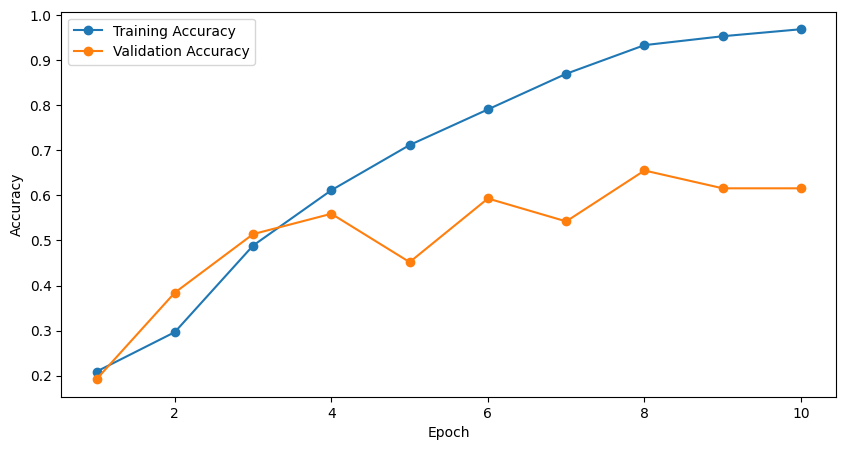

In [14]:
# Graph which show training_accuracy and validation_accuracy
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, EPOCHS+ 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracy, label='Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker = 'o')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [15]:
# epochs= 20
#history = model.fit(
 #   train_dataset,
  #  validation_data=validation_dataset,
   # epochs=EPOCHS
#)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

In [17]:
from tensorflow.keras.callbacks import   LearningRateScheduler
def scheduler(epoch, lr):
    if epoch < 5:
        return lr*0.1
    return lr

    lr_scheduler = LearningRateScheduler(scheduler)

In [18]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# stpe:1
# Convlution layer: 1
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2, 2)))
model.add(tf.keras.layers.Dropout(0.3))

# Convlution layer: 2
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2, 2)))
model.add(tf.keras.layers.Dropout(0.3))

# Convlution layer: 3
model.add(tf.keras.layers.Conv2D(128, (3, 3), activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2, 2)))
model.add(tf.keras.layers.Dropout(0.3))

# step: 2
# Flattening Layer
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5))

# step: 3
# Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

#Output layer
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [19]:
# COMPILATION
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [20]:
EPOCHS = 10

In [21]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 184s 8s/step - accuracy: 0.3206 - loss: 24.0854 - val_accuracy: 0.1186 - val_loss: 7.9435
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 165s 7s/step - accuracy: 0.5099 - loss: 1.9793 - val_accuracy: 0.2881 - val_loss: 50.1555
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 169s 7s/step - accuracy: 0.5367 - loss: 1.7176 - val_accuracy: 0.2768 - val_loss: 53.5402
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 167s 7s/step - accuracy: 0.5932 - loss: 1.0550 - val_accuracy: 0.2599 - val_loss: 50.6802
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 213s 8s/step - accuracy: 0.6766 - loss: 0.9077 - val_accuracy: 0.2655 - val_loss: 49.2756
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 191s 7s/step - accuracy: 0.7076 - loss: 0.8456 - val_accuracy: 0.2599 - val_loss: 39.3382
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 203s 7s/step - accuracy: 0.7556 - loss: 0.7927 - val_accuracy: 0.2994 - val_loss: 29.5568
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 177s 8s/step - accuracy: 0.7853 - loss: 0.5471 - val_accuracy: 0.2

In [22]:
# Data Augmentation
import tensorflow as tf
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, GlobalAveragePooling2D
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15)
])

## MobileNetV2 base model

In [23]:
# Transfer Learning

base_model =tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), include_top=False, weights='imagenet')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [24]:
base_model.trainable = False

model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
model.add(data_augmentation)
model.add(tf.keras.layers.Rescaling(1.0/255))

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))



In [25]:
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [26]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.4449 - loss: 1.5025 - val_accuracy: 0.5819 - val_loss: 1.0572
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.6384 - loss: 1.0049 - val_accuracy: 0.6102 - val_loss: 1.0658
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.6794 - loss: 0.8724 - val_accuracy: 0.6723 - val_loss: 0.9203
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.7359 - loss: 0.7504 - val_accuracy: 0.6610 - val_loss: 0.8607
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.7514 - loss: 0.7180 - val_accuracy: 0.6497 - val_loss: 0.9131
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.7994 - loss: 0.6011 - val_accuracy: 0.6554 - val_loss: 0.9376
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.8008 - loss: 0.6153 - val_accuracy: 0.6780 - val_loss: 0.8232
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.7966 - loss: 0.5562 - val_accuracy: 0.7006 - val_loss:

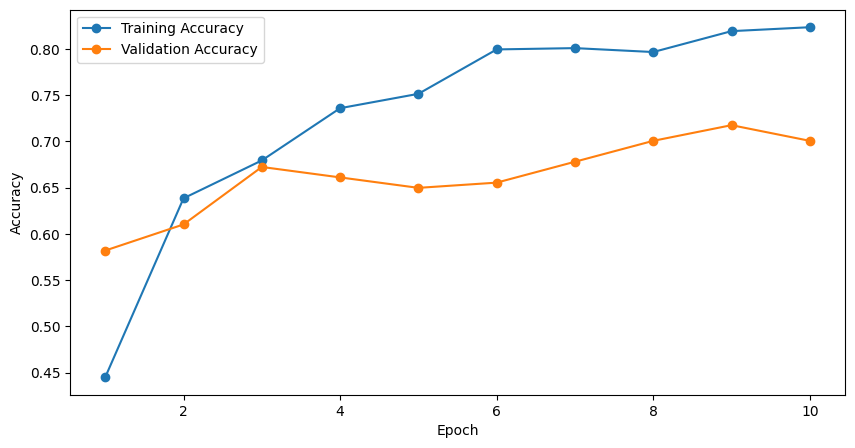

In [28]:
# Graph which show training_accuracy and validation_accuracy after applyng pre_trained MobileNetv2
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, 11)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracy, label='Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker = 'o')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [29]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.8432 - loss: 0.4806 - val_accuracy: 0.7458 - val_loss: 0.6913
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8305 - loss: 0.4706 - val_accuracy: 0.7514 - val_loss: 0.7439
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.8531 - loss: 0.4486 - val_accuracy: 0.7006 - val_loss: 0.8750
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.8503 - loss: 0.4363 - val_accuracy: 0.7175 - val_loss: 0.7873
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.8616 - loss: 0.3990 - val_accuracy: 0.7345 - val_loss: 0.7835
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.8602 - loss: 0.4373 - val_accuracy: 0.6667 - val_loss: 0.9475
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.8475 - loss: 0.4030 - val_accuracy: 0.7119 - val_loss: 0.7943
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.8616 - loss: 0.3884 - val_accuracy: 0.6836 - val_loss:

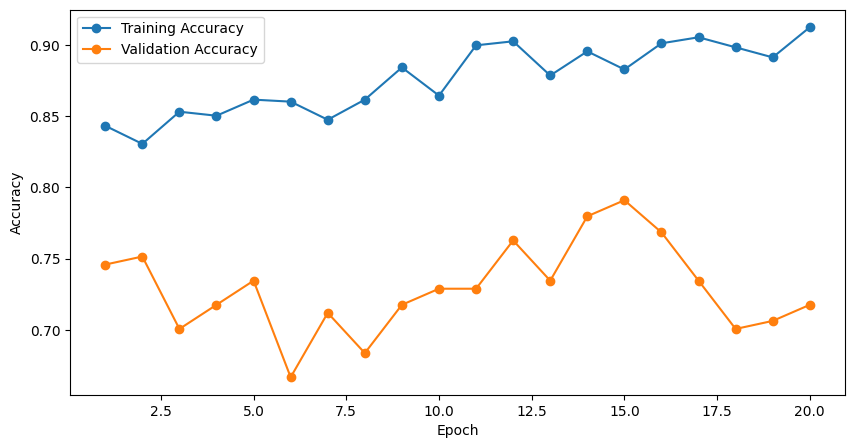

In [30]:
# Graph which show training_accuracy and validation_accuracy after applyng pre_trained MobileNetv2
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, 21)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracy, label='Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker = 'o')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [31]:
model.save('/content/drive/MyDrive/deeplearning_project/Data/Data/mobilenetv2_2.h5')

## EfficientNet

In [32]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
import os

In [33]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [34]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [35]:
class_names = train_dataset.class_names
print(class_names)

['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']


In [36]:
num_classes = len(class_names)
print(num_classes)

6


In [37]:
class_names = train_dataset.class_names

class_counts = {}
total_images = 0

for class_name in class_names:
    class_dir = os.path.join(dataset, class_name)
    count = len(os.listdir(class_dir))
    class_counts[class_name] = count
    total_images += count

num_classes = len(class_names)

class_weights = {}

for index, class_name in enumerate(class_names):
    class_weights[index] = total_images / (
        num_classes * class_counts[class_name]
    )

print("Class weights:", class_weights)

Class weights: {0: 0.7530224525043178, 1: 0.7491408934707904, 2: 0.7649122807017544, 3: 1.4110032362459546, 4: 2.106280193236715, 5: 1.1815718157181572}


In [38]:
print(type(class_names))
print(class_names)
print(class_counts)

<class 'list'>
['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
{'Bird-drop': 193, 'Clean': 194, 'Dusty': 190, 'Electrical-damage': 103, 'Physical-Damage': 69, 'Snow-Covered': 123}


In [39]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [40]:
train_images = []
train_labels = []

In [41]:
for images, labels in train_dataset:
  images = preprocess_input(images)
  train_images.append(images)
  train_labels.append(labels)

In [42]:
train_images = tf.concat(train_images, axis=0)
train_labels = tf.concat(train_labels, axis=0)

In [43]:
validation_imags = []
validation_labels = []

In [44]:
for images, labels in validation_dataset:
  images = preprocess_input(images)
  validation_imags.append(images)
  validation_labels.append(labels)

In [45]:
validation_images = tf.concat(validation_imags, axis=0)
validation_labels = tf.concat(validation_labels, axis=0)

In [46]:
base_model = tf.keras.applications.efficientnet.EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [47]:
base_model.trainable = False


In [48]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
model.add(data_augmentation)


model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [49]:
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [50]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [51]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 109s 4s/step - accuracy: 0.4972 - loss: 1.3178 - val_accuracy: 0.5932 - val_loss: 1.0124
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.7288 - loss: 0.8031 - val_accuracy: 0.7062 - val_loss: 0.7918
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step - accuracy: 0.7726 - loss: 0.6669 - val_accuracy: 0.7119 - val_loss: 0.7947
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 94s 4s/step - accuracy: 0.8079 - loss: 0.5638 - val_accuracy: 0.7458 - val_loss: 0.7328
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.8121 - loss: 0.5555 - val_accuracy: 0.7232 - val_loss: 0.6789
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.8418 - loss: 0.4483 - val_accuracy: 0.7797 - val_loss: 0.6246
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 145s 4s/step - accuracy: 0.8828 - loss: 0.3914 - val_accuracy: 0.8023 - val_loss: 0.5847
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.8644 - loss: 0.3957 - val_accuracy: 0.7853 - val_l

In [52]:
!pip install scikeras

In [55]:
# EfficientNetBO Hyper Parameter Optimization
!pip install keras-tuner

import keras_tuner as kt
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Reuse your train_dataset and validation_dataset (with preprocess_input already applied)
# Make sure they are defined as in your original code

def build_model(hp):
    base_model = EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    model = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(hp.Float("rotation_factor", min_value=0.05, max_value=0.3, step=0.05)),
        RandomZoom(hp.Float("zoom_factor", min_value=0.05, max_value=0.3, step=0.05)),
        base_model,
        GlobalAveragePooling2D(),
        Dropout(hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)),
        Dense(
            hp.Int("dense_units", min_value=64, max_value=512, step=64),
            activation='relu'
        ),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Setup Random Search Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,          # Same as n_iter before
    executions_per_trial=1,
    directory='kt_dir',
    project_name='efficientnet_tune',
    overwrite=True
)

# Optional: Early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Run the search
tuner.search(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5,
    callbacks=[early_stopping],
    class_weight=class_weights  # Handles imbalance
)

# Results
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hps.values)

best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate on validation
val_loss, val_acc = best_model.evaluate(validation_dataset)
print(f"Best validation accuracy: {val_acc:.4f}")

Trial 5 Complete [00h 08m 07s]
val_accuracy: 0.7344632744789124

Best val_accuracy So Far: 0.7627118825912476
Total elapsed time: 00h 45m 47s
Best hyperparameters:
{'rotation_factor': 0.15000000000000002, 'zoom_factor': 0.25, 'dropout_rate': 0.0, 'dense_units': 384, 'learning_rate': 0.00024305825869464035}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7627 - loss: 0.7472
Best validation accuracy: 0.7627


In [56]:
best_model.save('/content/drive/MyDrive/deeplearning_project/Data/Data/trained_effnet_finetuned.h5')